In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [135]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\customer_analytics.csv")

In [136]:
df

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,1192,49,Male,Bangalore,PhD,Single,58740.0,47,23,18,14,1,Laptop,1161
251,1157,35,Male,Hyderabad,PhD,Married,50930.0,45,15,5,29,4,Mobile,4568
252,1223,40,Male,Mumbai,Masters,Married,79540.0,9,17,13,17,4,Tablet,1743
253,1217,46,Female,Mumbai,Masters,Married,102840.0,54,24,2,12,0,Tablet,1526


In [137]:
df.head()

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB


In [139]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
count,255.000000,255.000000,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000
mean,1126.941176,37.729412,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,2795.07451
std,72.397256,9.767842,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,1328.77241
min,1001.000000,21.000000,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,566.00000
25%,1064.500000,29.000000,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,1542.50000
50%,1128.000000,38.000000,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,2705.00000
75%,1190.500000,46.000000,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,4001.00000
max,1250.000000,54.000000,474327.000000,95.000000,34.000000,24.000000,29.000000,4.000000,4996.00000


In [140]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'City', 'Education', 'MaritalStatus',
       'AnnualIncome', 'SpendingScore', 'YearsEmployed', 'PurchaseFrequency',
       'OnlineVisitsPerMonth', 'ReturnedItems', 'PreferredDevice',
       'LastPurchaseAmount'],
      dtype='object')

In [141]:
df.shape

(255, 14)

In [142]:
df.drop(columns=['CustomerID','Education','MaritalStatus','YearsEmployed'], inplace=True)

In [143]:
df.head()

,Age,Gender,City,AnnualIncome,SpendingScore,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,49,Male,Pune,82953.0,66,19,9,2,Laptop,3944
1,44,Male,Pune,60610.0,56,1,23,3,Desktop,3885
2,42,Male,Mumbai,35501.0,44,10,29,3,Laptop,3247
3,36,Female,Mumbai,99312.0,36,12,21,3,Mobile,2028
4,23,Male,Pune,46980.0,56,18,9,3,Tablet,1100


In [144]:
df.isnull().sum()

Age                      0
Gender                   0
City                     0
AnnualIncome            12
SpendingScore            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64

In [145]:
df['AnnualIncome'] = df['AnnualIncome'].fillna(df['AnnualIncome'].mean())


In [146]:
df.isnull().sum()

Age                     0
Gender                  0
City                    0
AnnualIncome            0
SpendingScore           0
PurchaseFrequency       0
OnlineVisitsPerMonth    0
ReturnedItems           0
PreferredDevice         0
LastPurchaseAmount      0
dtype: int64

In [147]:
df.duplicated().sum()

5

In [148]:
df = df.drop_duplicates()

In [149]:
df.duplicated().sum()

0

In [150]:
df.dtypes

Age                       int64
Gender                   object
City                     object
AnnualIncome            float64
SpendingScore             int64
PurchaseFrequency         int64
OnlineVisitsPerMonth      int64
ReturnedItems             int64
PreferredDevice          object
LastPurchaseAmount        int64
dtype: object

In [ ]:
LabelEncoder

In [151]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['City'] = le.fit_transform(df['City'])
df['PreferredDevice'] = le.fit_transform(df['PreferredDevice'])

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16140\1511265169.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = le.fit_transform(df['Gender'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16140\1511265169.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['City'] = le.fit_transform(df['City'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16140\1511265169.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

In [152]:
df.head()

,Age,Gender,City,AnnualIncome,SpendingScore,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,49,1,5,82953.0,66,19,9,2,1,3944
1,44,1,5,60610.0,56,1,23,3,0,3885
2,42,1,4,35501.0,44,10,29,3,1,3247
3,36,0,4,99312.0,36,12,21,3,2,2028
4,23,1,5,46980.0,56,18,9,3,3,1100


In [153]:
df.dtypes

Age                       int64
Gender                    int32
City                      int32
AnnualIncome            float64
SpendingScore             int64
PurchaseFrequency         int64
OnlineVisitsPerMonth      int64
ReturnedItems             int64
PreferredDevice           int32
LastPurchaseAmount        int64
dtype: object

In [155]:
df.skew()

Age                    -0.018677
Gender                 -0.048304
City                    0.066136
AnnualIncome            5.953223
SpendingScore          -0.084819
PurchaseFrequency       0.123012
OnlineVisitsPerMonth    0.024350
ReturnedItems           0.091838
PreferredDevice        -0.127367
LastPurchaseAmount      0.016660
dtype: float64

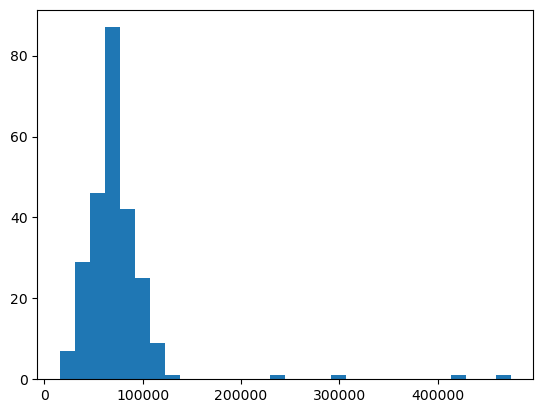

In [156]:
import matplotlib.pyplot as plt
plt.hist(df['AnnualIncome'], bins=30)
plt.show()

In [158]:
df.AnnualIncome.skew()

5.9532230791461025

In [160]:
df['AnnualIncome']=np.log1p(df['AnnualIncome'])

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16140\721863464.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AnnualIncome']=np.log1p(df['AnnualIncome'])


In [161]:
df.AnnualIncome.skew()

0.4011741610749436

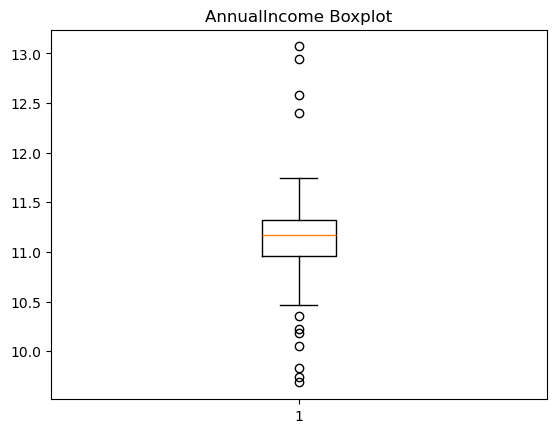

In [163]:
plt.boxplot(df['AnnualIncome'])
plt.title('AnnualIncome Boxplot')
plt.show()

In [164]:
Q1 = df['AnnualIncome'].quantile(0.25)
Q3 = df['AnnualIncome'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['AnnualIncome'] >= lower) & (df['AnnualIncome'] <= upper)]

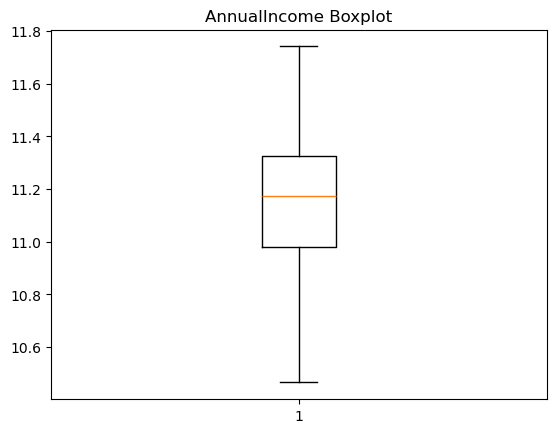

In [165]:
plt.boxplot(df['AnnualIncome'])
plt.title('AnnualIncome Boxplot')
plt.show()

In [172]:
X = df.drop('SpendingScore', axis=1)
y = df['SpendingScore']

In [173]:
####Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [174]:
### Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [176]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [180]:
# Make predictions
y_pred = model.predict(X_test)

In [181]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("R2 Score (RF):", r2_score(y_test, y_pred_rf))

R2 Score (RF): 0.0159527151270753
